# Symbolic Aggregate approXimation (SAX)

Symbolic Aggregate approXimation (SAX) converts a real-valued time series into a compact symbolic representation. It first reduces the series with Piecewise Aggregate Approximation (PAA), then maps each reduced value to a symbol using distribution-based breakpoints.

This notebook demonstrates the `aeon` SAX transformer with a custom alphabet, inverse reconstruction, and optional sliding-window transformation.

## Table of contents

1. [Imports](#imports)
2. [Load an example dataset](#load-an-example-dataset)
3. [Standard SAX transformation](#standard-sax-transformation)
4. [Visualise the SAX representation](#visualise-the-sax-representation)
5. [Windowed SAX transformation](#windowed-sax-transformation)
6. [Visualise a windowed SAX word](#visualise-a-windowed-sax-word)
7. [Summary](#summary)

## What you will learn

- How SAX represents a time series as a word of symbols.
- How Gaussian breakpoints determine the assigned symbols.
- How to reconstruct an approximate series with `inverse_sax`.
- How windowing produces one SAX word per sliding window.


## Imports

Import the numerical, plotting, and `aeon` utilities used throughout the notebook.

In [1]:
import numpy as np

from aeon.datasets import load_classification
from aeon.transformations.collection.dictionary_based import SAX

## Load an example dataset

We use the univariate `ArrowHead` classification dataset. `aeon` stores collections in a three-dimensional array with shape `(n_cases, n_channels, n_timepoints)`.

In [2]:
X_train, y_train = load_classification(name="ArrowHead", split="train")

print(f"Training data shape: {X_train.shape}")
print(f"Class labels: {np.unique(y_train)}")

Training data shape: (36, 1, 251)
Class labels: ['0' '1' '2']


## Standard SAX transformation

For the standard transformation, the full series is reduced to `n_segments` PAA values. Each value is assigned to one of `alphabet_size` Gaussian intervals and replaced by the corresponding alphabet element.

With `n_segments=8`, each input series becomes one SAX word containing eight symbols.

In [3]:
n_segments = 8
alphabet_size = 4
alphabet = ["a", "b", "c", "d"]

sax = SAX(
    n_segments=n_segments,
    alphabet_size=alphabet_size,
    alphabet=alphabet,
    znormalized=False
)

X_sax = sax.fit_transform(X_train)
X_sax_inverse = sax.inverse_sax(
    X_sax,
    original_length=X_train.shape[-1],
)

print(f"SAX output shape: {X_sax.shape}")
print(f"Inverse SAX output shape: {X_sax_inverse.shape}")
print("First SAX word:", X_sax[0, 0])

SAX output shape: (36, 1, 8)
Inverse SAX output shape: (36, 1, 251)
First SAX word: ['a' 'd' 'c' 'b' 'b' 'c' 'd' 'a']


## Visualise the SAX representation

The plot below combines four views of the transformation:

- the original series;
- the inverse SAX approximation;
- the symbol assigned to each PAA segment;
- the Gaussian distribution and its SAX breakpoints, denoted by $\beta_i$.

The inverse curve is an approximation rather than an exact reconstruction because each symbol represents an interval of values.

/tmp/ipykernel_130602/2784485731.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


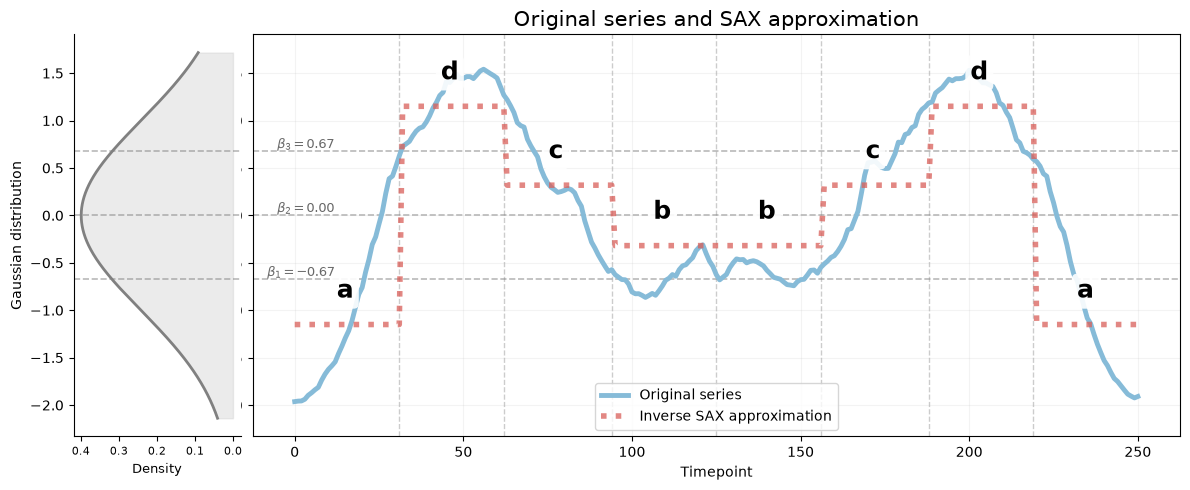

In [4]:
from aeon.visualisation import plot_sax_representation

fig, ax = plot_sax_representation(
    X_train,
    X_sax,
    X_sax_inverse,
    sax,
    series_index=0,
    channel_index=0,
)
fig.show()

## Windowed SAX transformation

Windowing applies SAX independently to shorter subsequences rather than once to the complete series.

- `window_size` is the number of timepoints in each window.
- `stride` is the number of timepoints by which the window advances.
- Each window produces one word of length `n_segments`.

For windowed output, the array shape is

```text
(n_cases, n_channels, n_windows, n_segments)
```

When windows overlap, `inverse_sax` combines their reconstructed values by overlap averaging. A smaller stride creates more words and stronger overlap.

In [7]:
n_segments = 4
alphabet_size = 4
alphabet = ["a", "b", "c", "d"]
window_size = 64
stride = window_size // 2  # overlap of 50% between windows

windowed_sax = SAX(
    n_segments=n_segments,
    alphabet_size=alphabet_size,
    alphabet=alphabet,
    window_size=window_size,
    stride=stride,
    znormalized=False
)

X_windowed_sax = windowed_sax.fit_transform(X_train)
X_windowed_inverse = windowed_sax.inverse_sax(
    X_windowed_sax,
    original_length=X_train.shape[-1],
)

print(f"Windowed SAX output shape: {X_windowed_sax.shape}")
print(f"Windowed inverse output shape: {X_windowed_inverse.shape}")
print("First three SAX words for the first series:")
print(X_windowed_sax[0, 0, :3])

Windowed SAX output shape: (36, 1, 6, 4)
Windowed inverse output shape: (36, 1, 251)
First three SAX words for the first series:
[['a' 'b' 'd' 'd']
 ['c' 'd' 'b' 'a']
 ['d' 'c' 'a' 'b']]


## Visualise a windowed SAX word

The complete red curve is the overlap-averaged inverse reconstruction. The shaded region identifies the selected window, while the annotations show the symbols in that window's SAX word.

Change `window_index` to inspect another word.

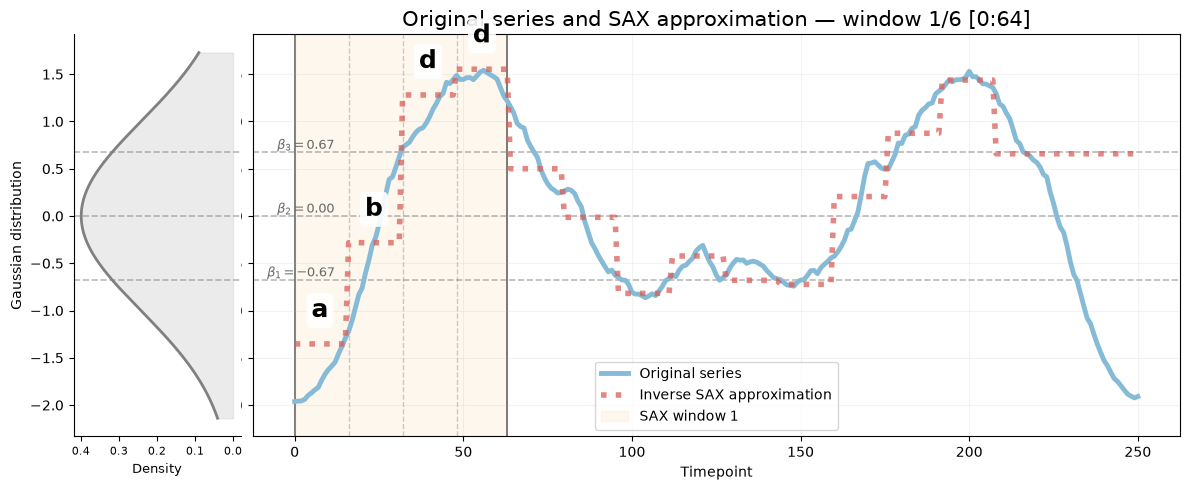

In [8]:
window_index = 0

fig, ax = plot_sax_representation(
    X_train,
    X_windowed_sax,
    X_windowed_inverse,
    windowed_sax,
    series_index=0,
    channel_index=0,
    window_index=window_index,
)
fig.savefig("sax_representation.pdf", bbox_inches="tight", dpi=300)

## Summary

SAX provides a compact and interpretable representation of time-series data:

- Standard SAX returns one symbolic word per channel and series.
- A custom alphabet changes the displayed symbols without changing the breakpoint assignment.
- The inverse transformation maps symbols to representative values and provides an approximate reconstruction.
- Windowed SAX returns one word per window and can capture local temporal patterns.
- With overlapping windows, inverse reconstruction averages the contributions at each timepoint.

The main parameters control different aspects of the representation:

| Parameter | Role |
| --- | --- |
| `n_segments` | Number of PAA sections and symbols in each word |
| `alphabet_size` | Number of Gaussian intervals and available symbols |
| `alphabet` | Optional custom labels for the intervals |
| `window_size` | Number of timepoints transformed into each word |
| `stride` | Distance between consecutive window starts |

For downstream dictionary-based methods, the windowed SAX words can be counted or compared as local symbolic patterns.